## Pokemon Dataset Machine Learning

### Load libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import DataFrame, Series

### Read dataset

In [4]:
data_pokemon = pd.read_csv("pokemon.csv")

In [5]:
pd.DataFrame(data_pokemon)

,SI no,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


### Statistical Dataset Info

In [6]:
data_pokemon.describe()

,SI no,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [7]:
data_pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   SI no       800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [8]:
data_pokemon.shape

(800, 13)

### Graphical Analysis

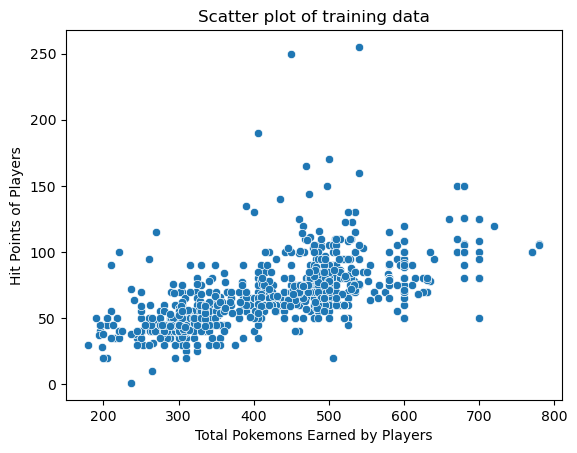

In [9]:
# Plot showing Player performance : Total points earned v/s Hit points

import seaborn as sns
ax = sns.scatterplot(x='Total', y='HP', data=data_pokemon)
ax.set(xlabel='Total Pokemons Earned by Players', ylabel='Hit Points of Players', title='Scatter plot of training data');

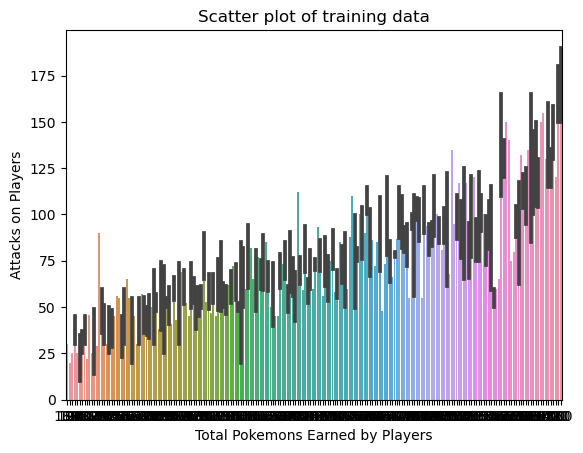

In [10]:
# Plot showing Player performance : Total points earned v/s Attacks on players

ax = sns.barplot(x='Total', y='Attack', data=data_pokemon)
ax.set(xlabel='Total Pokemons Earned by Players', ylabel='Attacks on Players', title='Scatter plot of training data');

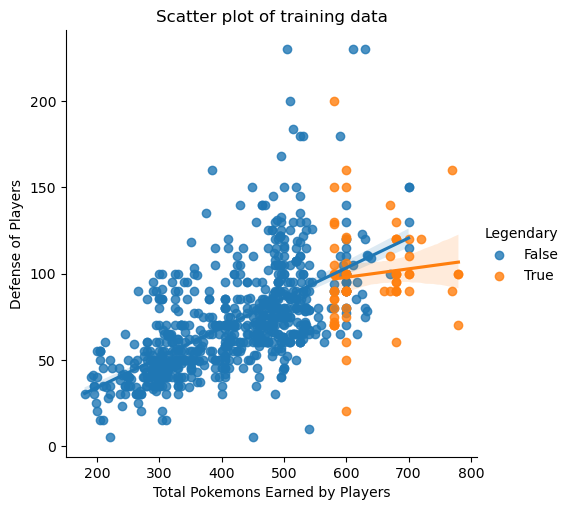

In [11]:
# Plot showing Player performance : Total points earned v/s Defense made by players

ax = sns.lmplot(x = 'Total', y = 'Defense', data = data_pokemon, hue = 'Legendary')
ax.set(xlabel='Total Pokemons Earned by Players', ylabel='Defense of Players', title='Scatter plot of training data');

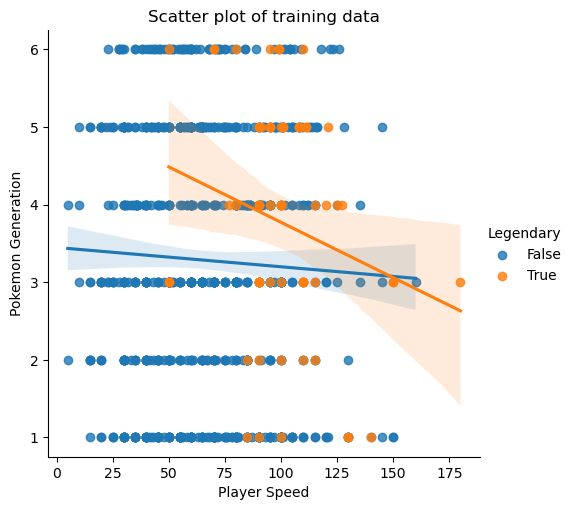

In [12]:
# Plot showing Player performance : Player speed v/s Game generation

ax = sns.lmplot(x = 'Speed', y = 'Generation', data = data_pokemon, hue = 'Legendary')
ax.set(xlabel='Player Speed', ylabel='Pokemon Generation', title='Scatter plot of training data');

### Data preprocessing

In [13]:
data_pokemon.isnull().sum()

SI no           0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [14]:
# we will rename column to remove spaces

data_pokemon.rename(columns={'Type 2': 'Type2'}, inplace=True)

In [15]:
# we will rename column to remove spaces

data_pokemon.rename(columns={'Type 1': 'Type1'}, inplace=True)

In [16]:
# new column name 

data_pokemon.head(1)

,SI no,Name,Type1,Type2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False


In [17]:
# column 'Embarked' has null values, we will use 'mode' to fill missing values

# lets check 'mode' for column 'Embarked'

data_pokemon['Type2'].mode()[0]

'Flying'

In [18]:
# fill missing values of the categorical column with 'mode'

data_pokemon['Type2'] = data_pokemon['Type2'].fillna(data_pokemon['Type2'].mode()[0])

In [19]:
# now we have zero null values in Fare column

data_pokemon['Type2'].isnull().sum()

0

### Converting Dtype

In [20]:
data_pokemon["Name"] = data_pokemon["Name"].astype("category")
data_pokemon["Type1"].dtype

dtype('O')

In [21]:
data_pokemon["Type1"] = data_pokemon["Type1"].astype("category")
data_pokemon["Type1"].dtype

CategoricalDtype(categories=['Bug', 'Dark', 'Dragon', 'Electric', 'Fairy', 'Fighting',
                  'Fire', 'Flying', 'Ghost', 'Grass', 'Ground', 'Ice',
                  'Normal', 'Poison', 'Psychic', 'Rock', 'Steel', 'Water'],
, ordered=False)

In [22]:
data_pokemon["Type2"] = data_pokemon["Type2"].astype("category")
data_pokemon["Type2"].dtype

CategoricalDtype(categories=['Bug', 'Dark', 'Dragon', 'Electric', 'Fairy', 'Fighting',
                  'Fire', 'Flying', 'Ghost', 'Grass', 'Ground', 'Ice',
                  'Normal', 'Poison', 'Psychic', 'Rock', 'Steel', 'Water'],
, ordered=False)

In [23]:
data_pokemon["Legendary"] = data_pokemon["Legendary"].astype("category")
data_pokemon["Legendary"].dtype

CategoricalDtype(categories=[False, True], ordered=False)

### Label encoding

In [24]:
# change dtype to Int for below columns 

from sklearn.preprocessing import LabelEncoder
cols = ['Name', 'Type1', 'Type2', 'Legendary']
le = LabelEncoder()

for col in cols:
    data_pokemon[col]=le.fit_transform(data_pokemon[col])
data_pokemon.head()

,SI no,Name,Type1,Type2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,80,9,13,318,45,49,49,65,65,45,1,0
1,2,329,9,13,405,60,62,63,80,80,60,1,0
2,3,745,9,13,525,80,82,83,100,100,80,1,0
3,3,746,9,13,625,80,100,123,122,120,80,1,0
4,4,102,6,7,309,39,52,43,60,50,65,1,0


In [25]:
# Input split

X = data_pokemon.drop(columns=['SI no', 'Legendary'], axis=1)
y = data_pokemon['Legendary']

In [26]:
X

,Name,Type1,Type2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
0,80,9,13,318,45,49,49,65,65,45,1
1,329,9,13,405,60,62,63,80,80,60,1
2,745,9,13,525,80,82,83,100,100,80,1
3,746,9,13,625,80,100,123,122,120,80,1
4,102,6,7,309,39,52,43,60,50,65,1
...,...,...,...,...,...,...,...,...,...,...,...
795,160,15,4,600,50,100,150,100,150,50,6
796,161,15,4,700,50,160,110,160,110,110,6
797,314,14,8,600,80,110,60,150,130,70,6
798,315,14,1,680,80,160,60,170,130,80,6


In [27]:
y

0      0
1      0
2      0
3      0
4      0
      ..
795    1
796    1
797    1
798    1
799    1
Name: Legendary, Length: 800, dtype: int32

### Machine Learning Model Training - Train / Split data

In [28]:
# Split data test / train model

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [29]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
# training
model.fit(X_train, y_train)
# testing
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("F1 Score:",f1_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99       150
           1       0.71      1.00      0.83        10

    accuracy                           0.97       160
   macro avg       0.86      0.99      0.91       160
weighted avg       0.98      0.97      0.98       160

F1 Score: 0.8333333333333333


In [30]:
from xgboost  import XGBClassifier
model = XGBClassifier()
# training
model.fit(X_train, y_train)
# testing
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("F1 Score:",f1_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       150
           1       0.60      0.90      0.72        10

    accuracy                           0.96       160
   macro avg       0.80      0.93      0.85       160
weighted avg       0.97      0.96      0.96       160

F1 Score: 0.7200000000000001


In [31]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
# training
model.fit(X_train, y_train)
# testing
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("F1 Score:",f1_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       150
           1       0.56      0.90      0.69        10

    accuracy                           0.95       160
   macro avg       0.78      0.93      0.83       160
weighted avg       0.97      0.95      0.96       160

F1 Score: 0.6923076923076923
